# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
 usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:

print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- En Users, la columna city hay 469 nulos que supone un 11,73% de los datos. Conviene revisar para imputar y la columna churn_date tiene 3534 nulos que supone un 88,35% probablemente signifique que todavía el cliente permanece activo.
- En Usage, la columna date tiene  0,125% de nulos, son mínimos y deben de revisarse, en durationes un 55.19% y la length un 44,74%. Parece estar relacionada con el tipo de actividad (type), es probable que duration se use para llamadas dejando lenght en nulo y los mensajes tengan dato en length y nulo en duration.

In [13]:
usage[['type', 'duration', 'length']].sample(10)

,type,duration,length
21736,text,NaN,72.0
15345,call,3.77,NaN
11632,call,9.68,NaN
25037,text,NaN,58.0
24428,call,0.97,NaN
10029,call,1.03,NaN
8772,text,NaN,39.0
38076,text,NaN,60.0
35633,call,0.97,NaN
9110,text,NaN,105.0


Comprueba la teoria de la relacion en entre el type - duration y lenght.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
users['user_id'].nunique()

4000

In [15]:
users["age"].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [16]:
users["city"].describe()



count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [17]:
(users['age'] == -999).sum()

55

In [18]:
basicos = (users['plan'] == 'Basico').sum()
premium = (users['plan'] == 'Premium').sum()
print("Planes Básico:", basicos)
print("Planes Premium:", premium)



Planes Básico: 2595
Planes Premium: 1405


In [19]:
users['churn_date'].value_counts()

1,72238E+18    6
1,71763E+18    6
1,71841E+18    6
1,72817E+18    5
1,72584E+18    5
              ..
1,7299E+18     1
1,72662E+18    1
1,72316E+18    1
1,73051E+18    1
1,7178E+18     1
Name: churn_date, Length: 197, dtype: int64

La columna de **user_id** sería importante como identificador para unir tablas, no tiene nulos y tiene 4000 valores únicos que corresponden con los 4000 valores que tiene la columna.

Por su parte, la columna **age** no contiene valores nulos, pero presenta un valor inválido de -999, 55 veces, que probablemente fue utilizado para representar un dato faltante o un error de captura representa solo el 1.375% de los datos.

En **city** se identificaron 469 valores faltantes (11.73%), mientras que las 3,531 observaciones restantes corresponden a 7 ciudades diferentes, siendo Bogotá la más representada con 808 usuarios. 

Los **planes** se identificó que 2,595 usuarios (64.9%) están suscritos al plan Básico, mientras que 1,405 usuarios (35.1%) utilizan el plan Premium. Esto indica que el plan Básico es el más popular entre los clientes y concentra aproximadamente dos tercios de los usuarios, por lo que cualquier análisis posterior del comportamiento o consumo deberá considerar que la distribución entre ambos planes no es uniforme. 


La columna de **churn _date** tiene 3534 NaN, se entiende que es la fecha de cancelación asi que  no supone un problema ya que se interpreta como cliente activo y los que tienen fecha, los clientes que cancelaron. 




Para el database de Usage : 

In [20]:

print("Valores nulos:", usage['id'].isna().sum())
print("Registros duplicados:", usage['id'].duplicated().sum())
print("IDs únicos:", usage['id'].nunique())


Valores nulos: 0
Registros duplicados: 0
IDs únicos: 40000


In [21]:

print("Valores nulos:", usage['user_id'].isna().sum())
print("Usuarios únicos:", usage['user_id'].nunique())
print("\nUsuarios con más interacciones:")
print(usage['user_id'].value_counts().head())



Valores nulos: 0
Usuarios únicos: 3999

Usuarios con más interacciones:
13819    27
13100    22
13772    22
13255    22
13475    21
Name: user_id, dtype: int64


Entendemos user_id como identificador unico de persona e id como el identificador único de cada registro de uso., La columna **user_id**  no presenta valores nulos y contiene 3,999 usuarios únicos. Al comparar esta cifra con la tabla de usuarios, que registra 4,000 clientes, se observa que un usuario no tiene registros de llamadas ni mensajes en el período analizado. Esta situación es coherente con la posibilidad de que dicho usuario no haya utilizado el servicio durante ese intervalo y no representa necesariamente un error en los datos.

In [22]:
users_ids = set(users['user_id'])
usage_ids = set(usage['user_id'])

print(users_ids - usage_ids)

{11082}


El user_id 11082 no tiene todavía uso del servicio 

In [23]:

usage['type'].unique()



array(['call', 'text'], dtype=object)

La columna **type** contiene únicamente dos categorías de actividad: call y text, que representan llamadas y mensajes de texto, respectivamente. No se identifican valores inesperados o categorías adicionales, lo que indica que la variable está correctamente codificada y presenta una estructura consistente. Esta clasificación permitirá analizar por separado el comportamiento de las llamadas y los mensajes, ya que cada tipo de actividad utiliza variables diferentes (duration para llamadas y length para mensajes).

In [24]:

 cols = ['duration', 'length']

for col in cols:
    print(col)
    print(usage[col].describe())
    print()  


duration
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

length
count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64



Duration (duración de las llamadas)

La columna duration contiene 17,924 registros válidos, lo que indica que solo las llamadas tienen una duración asociada. La duración promedio es de 5.2 minutos, mientras que la mediana es de 3.5 minutos, lo que sugiere una distribución sesgada hacia la derecha: la mayoría de las llamadas son relativamente cortas y unas pocas llamadas muy largas elevan el promedio. El 50% de las llamadas dura entre 1.44 y 6.99 minutos (entre el primer y el tercer cuartil). Además, se observan valores mínimos de 0 minutos, que podrían corresponder a llamadas no completadas o registros sin duración efectiva, y un máximo de 120 minutos, que conviene revisar para confirmar que no se trata de un valor atípico o un límite establecido por el sistema.

Length (longitud de los mensajes)

La columna length contiene 22,104 registros válidos, correspondientes a los mensajes de texto. La longitud media es de 52.1 caracteres y la mediana es de 50 caracteres, lo que indica una distribución más centrada que la de las llamadas. El 50% de los mensajes tiene entre 37 y 64 caracteres, por lo que la mayoría son relativamente cortos. Sin embargo, el valor máximo de 1,490 caracteres es muy superior al resto de la distribución y podría representar un mensaje excepcionalmente largo o un posible valor atípico que merece una revisión. Asimismo, existen mensajes con longitud 0, lo que podría indicar mensajes vacíos, errores de registro o eventos especiales.


En cuanto a las columas de las fechas en ambas bases datos necesitan una estandarización y revisión.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [25]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print(users['reg_date'].dtype)


datetime64[ns]


In [26]:
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print(users['reg_date'].dtype)



datetime64[ns]


In [27]:
print(users['reg_date'].dt.year.value_counts().sort_index())


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


In [28]:
print(usage['date'].dt.year.value_counts().sort_index())


2024.0    39950
Name: date, dtype: int64


- users.reg_date contiene registros de 2022, 2023, 2024 y 2026.
- usage.date solo contiene actividad de 2024.
- El proyecto dice que se tomaron datos hasta el 2024, así 2026 debe de ser un error. 

La columna reg_date contiene registros entre 2022 y 2026, mientras que la tabla usage únicamente registra actividad durante 2024. Esta diferencia no implica necesariamente un error, ya que es posible que el conjunto de datos de uso corresponda exclusivamente al año 2024. No obstante, conviene revisar la documentación del proyecto  y verificar la coherencia entre ambas.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

In [29]:
for year in [2022, 2023, 2024, 2026]:
    print(f"\nRegistros del año {year}:")
    print(users[users['reg_date'].dt.year == year].head())


Registros del año 2022:
   user_id first_name last_name  age      city                      reg_date  \
0    10000     Carlos    Garcia   38  Medellín 2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ? 2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX 2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá 2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL 2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  

Registros del año 2023:
      user_id first_name last_name  age      city  \
1333    11333     Carlos    Torres   74  Medellín   
1334    11334       Luis   Ramirez   28       NaN   
1335    11335      Sofia     Lopez   51       MTY   
1336    11336    Mariana    Torres   56       GDL   
1337    11337    Mariana   Ramirez   21    Bogotá   

      

Breve exploración a ver si la lógica de los datos parece consistente y si las fechas parecen con formato consistente y los registros coherentes. Se identificaron 40 usuarios (1% del total) con una fecha de registro correspondiente a 2026, aunque la documentación del proyecto indica que el período de estudio finaliza en 2024. Dado que no es posible determinar la fecha correcta únicamente a partir de la información disponible, estos registros deben documentarse como una posible inconsistencia y, si el análisis se limita al período 2022–2024, considerar su exclusión de los análisis temporales.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [30]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users["age"] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users["age"].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [31]:
users['city'] = users['city'].replace('?', pd.NA)
print(users['city'].isna().sum())


565


In [32]:
#reemplazar por un valor nulo (NaT) todas las fechas de reg_date cuyo año sea mayor que 2024 y comprobación.
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
print(users['reg_date'].dt.year.value_counts().sort_index())


2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [33]:
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [34]:
 usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False) 


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Efectivamente comprobamos que la  `duration` está relacionada con las llamadas  y `length`con los mensajes de texto, asi los nulos son característica intrínseca al dato.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [35]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').apply(
    lambda x: pd.Series({
        'cant_mensajes': (x['type'] == 'text').sum(),
        'cant_llamadas': (x['type'] == 'call').sum(),
        'cant_minutos_llamada': x['duration'].sum()
    })
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7.0,3.0,23.70
1,10001,5.0,10.0,33.18
2,10002,5.0,2.0,10.74


In [36]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [37]:
user_profile.describe()


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [38]:
# Distribución porcentual de los planes
print(user_profile['plan'].value_counts(normalize=True) * 100)


Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

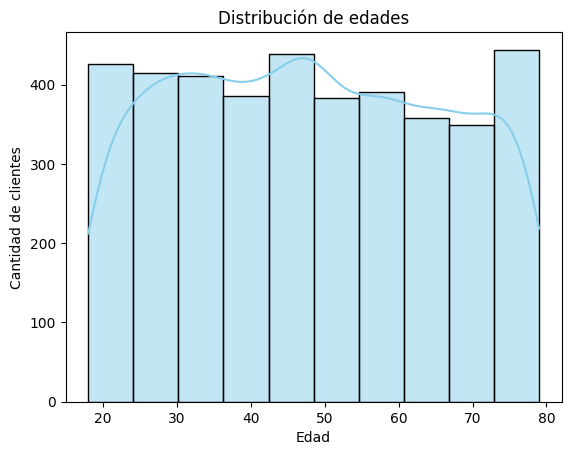

In [39]:
# Histograma para visualizar la edad (age)

sns.histplot(user_profile['age'], bins=10, color='skyblue', kde=True)

plt.xlabel('Edad')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de edades')

plt.show()


💡Insights: 
La distribución es bastante uniforme entre los 18 y 79 años. No se aprecia una concentración marcada en un grupo de edad específico; las barras tienen alturas similares a lo largo de todo el rango.

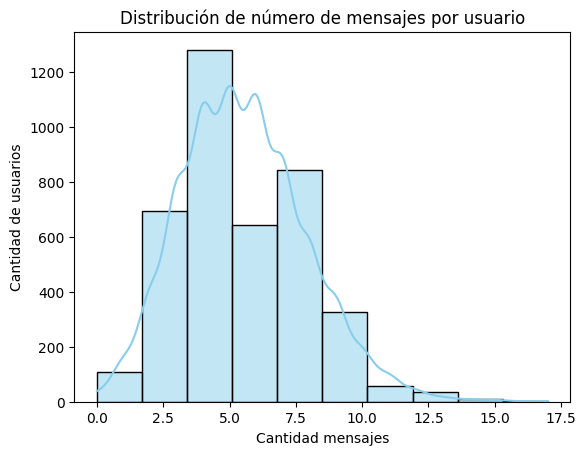

In [40]:
# Histograma para visualizar la cant_mensajes

sns.histplot(user_profile['cant_mensajes'], bins=10, color='skyblue', kde=True)

plt.xlabel('Cantidad mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de número de mensajes por usuario')

plt.show()

💡Insights: 
La mayoría de los usuarios envía entre 3 y 7 mensajes, con un máximo de frecuencia alrededor de 4 o 5 mensajes. La distribución presenta un sesgo positivo, ya que el número de usuarios disminuye conforme aumenta la cantidad de mensajes enviados. Aunque existen usuarios con un volumen de mensajes superior a 10, estos casos son poco frecuentes y no constituyen valores atípicos evidentes. En general, el comportamiento de mensajería es relativamente homogéneo y se concentra en niveles bajos o moderados de uso.

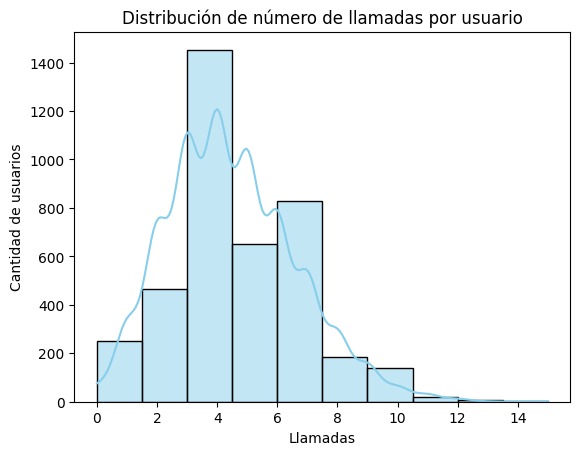

In [41]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile['cant_llamadas'], bins=10, color='skyblue', kde=True)

plt.xlabel('Llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de número de llamadas por usuario')

plt.show()

💡Insights: 
La mayoría de los usuarios realiza entre 3 y 6 llamadas, con un máximo de frecuencia alrededor de 4 llamadas por usuario. La distribución muestra un sesgo positivo, ya que el número de usuarios disminuye conforme aumenta la cantidad de llamadas realizadas. Los usuarios con más de 10 llamadas son poco frecuentes y no parecen constituir valores atípicos que requieran un tratamiento especial. En conjunto, la variable refleja un patrón de uso moderado del servicio de llamadas por parte de la mayoría de los clientes.

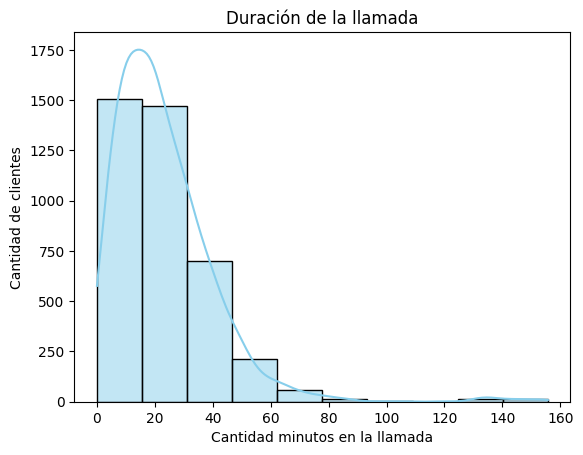

In [42]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile['cant_minutos_llamada'], bins=10, color='skyblue', kde=True)

plt.xlabel('Cantidad minutos en la llamada')
plt.ylabel('Cantidad de clientes')
plt.title('Duración de la llamada')

plt.show()

💡Insights: 
La duración de las llamadas por usuario presenta una distribución claramente asimétrica hacia la derecha. La mayoría de los usuarios acumula entre 5 y 30 minutos de llamadas, mientras que un pequeño grupo registra consumos significativamente mayores, alcanzando hasta 160 minutos. Estos valores elevados parecen corresponder a usuarios de alto consumo más que a errores evidentes en los datos, por lo que conviene evaluarlos antes de decidir si requieren algún tratamiento durante el análisis.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

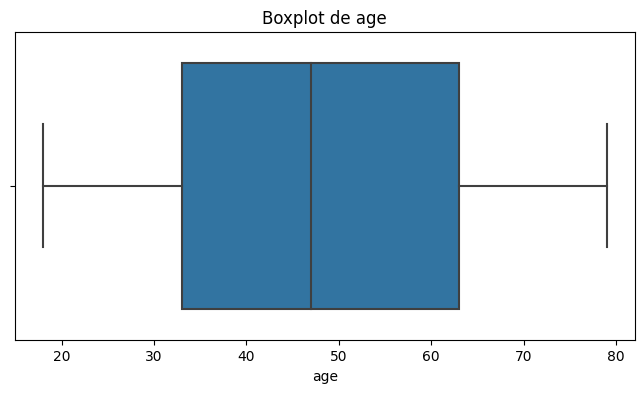

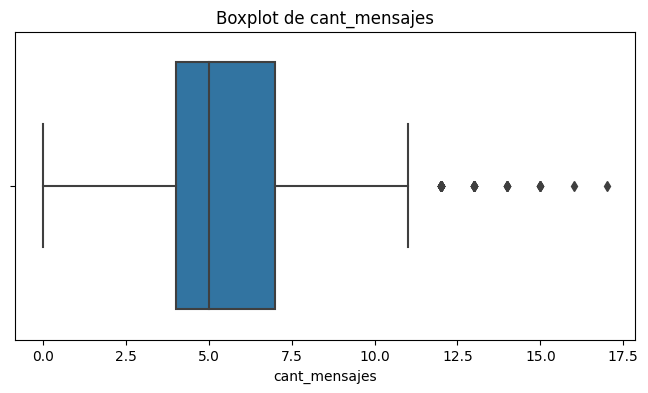

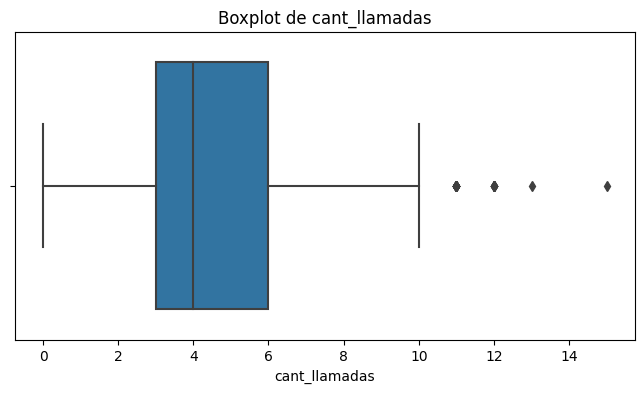

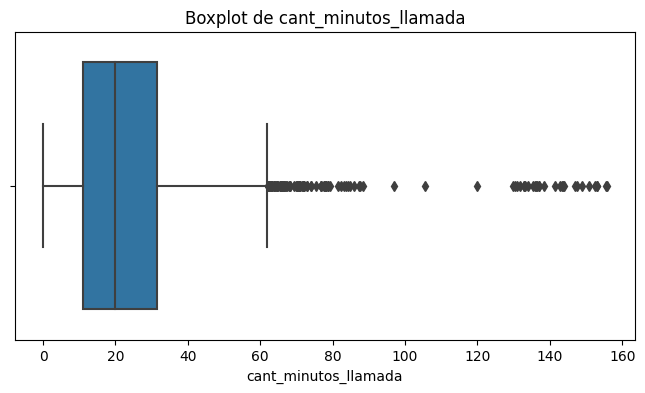

In [43]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()


💡Insights: 
- Age: El boxplot muestra una población repartida homogeneamente con represenatción en todas las edaddes desde los 18 a los 79. El grueso de usuarios estan entre los 33 y 63 con media en los 47. No hay outliners  
- cant_mensajes: La mayoria de los usuarios manda entre 3-7 mensajes. Hay un sesgo positivo, disminuye el numero de clientes cuando suben los mensajes. Si se observan ciertos usuarios que destacan por su uso intenso lo que genera un sesgo positivo(outliers).
- cant_llamadas: La mayoría de los usuarios realiza entre 3 y 6 llamadas pero igual hay sesgo positivo por algunos usuarios que superan las 10 llamadas. Muestra algunos outliers
- cant_minutos_llamada: El boxplot muestra que la mayor parte de los usuarios acumula entre 10 y 30 minutos de llamadas, con una mediana cercana a 20 minutos. La distribución presenta un marcado sesgo positivo y un número considerable de valores atípicos por encima de los 60 minutos. Estos valores elevados parecen corresponder a usuarios con un consumo intensivo del servicio más que a errores de registro. 

In [44]:

# Calcular límites con el método IQR

columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")



age
Q1: 33.00
Q3: 63.00
IQR: 30.00
Límite inferior: -12.00
Límite superior: 108.00

cant_mensajes
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50

cant_llamadas
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50

cant_minutos_llamada
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86


💡Insights: 

- cant_mensajes

Recomendación: Mantener los outliers.

Justificación: La cantidad de mensajes enviados puede variar considerablemente entre usuarios. Es normal que algunos clientes utilicen el servicio de mensajería con mucha más frecuencia que otros. Mientras no existan valores imposibles o errores de captura, estos usuarios representan un comportamiento real.

- cant_llamadas
  
Recomendación: Mantener los outliers.

Justificación: Al igual que ocurre con los mensajes, es esperable que algunos usuarios realicen muchas más llamadas que el promedio. Los valores altos pueden corresponder a clientes con un uso intensivo del servicio y no constituyen evidencia de errores en los datos. Eliminarlos podría sesgar el análisis y subestimar el comportamiento de los usuarios de mayor consumo.

- cant_minutos_llamada:
  
  Recomendación: Mantener los outliers, aunque analizarlos con mayor atención.

Justificación: Esta variable presenta una cola larga y un número importante de valores atípicos. Sin embargo, el histograma y el boxplot muestran que esos valores siguen una tendencia continua y no aparecen como observaciones aisladas. Es razonable que algunos usuarios acumulen muchos más minutos de llamadas que el resto.

Aunque el método del IQR identifica valores atípicos en estas tres variables, no existe evidencia de que correspondan a errores de los datos. Dado que representan distintos niveles de uso del servicio y son coherentes con el contexto de una empresa, se recomienda conservarlos para evitar perder información relevante sobre los usuarios de mayor consumo. Antes de considerar su eliminación, sería necesario contar con reglas de negocio que indiquen qué valores son realmente imposibles o inconsistentes.
  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [62]:
import numpy as np



# Condiciones
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# Valores a asignar
valores = ['Bajo uso', 'Uso medio']

# Crear la nueva columna
user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)

# Verificar el resultado
user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()



,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [56]:

# Crear columna grupo_edad
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60),
    (user_profile['age'] >= 60)
]

valores = [
    'Joven',
    'Adulto',
    'Adulto Mayor'
]

user_profile['grupo_edad'] = np.select(condiciones_edad, valores)

# Verificar el resultado
print(user_profile[['age', 'grupo_edad']].head())

    age    grupo_edad
0  38.0        Adulto
1  53.0        Adulto
2  57.0        Adulto
3  69.0  Adulto Mayor
4  63.0  Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

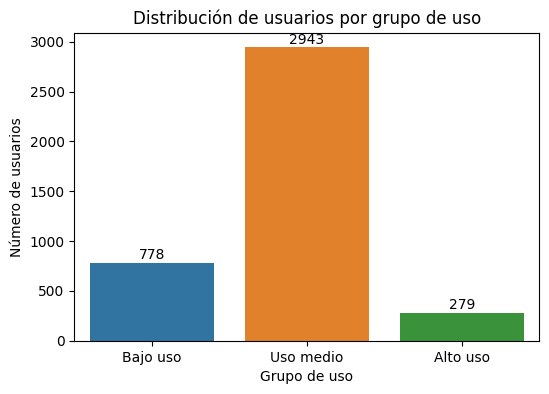

In [64]:
# Visualización de los segmentos por uso

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')

# Añadir el valor encima de cada barra
for barra in ax.patches:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura + 10,              # separación sobre la barra
        f'{int(altura)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()


El mercado está dominado por consumo moderado (73.6%); los extremos son minoría (26.4% combinado).
**Conclusiones preliminares:**
- El segmento de Uso medio (73.6%) es el principal mercado de crecimiento. Al ser la mayoría de la base de clientes, pequeñas acciones para incrementar ligeramente su consumo (por ejemplo, paquetes adicionales de minutos o mensajes, promociones o programas de fidelización) podrían generar un impacto importante en los ingresos.
- Los usuarios de Bajo uso (19.4%) presentan riesgo de baja vinculación. Este grupo podría estar utilizando el servicio de forma esporádica o tener una mayor probabilidad de abandonar la compañía. Sería recomendable diseñar campañas de activación, descuentos o beneficios que incentiven un mayor uso antes de que decidan cancelar el servicio.
- Los usuarios de Alto uso (7.0%) son clientes estratégicos. Aunque representan una proporción pequeña, es probable que concentren una parte significativa del consumo total. Este segmento puede ser prioritario para ofrecer planes Premium, beneficios exclusivos o programas de fidelización que reduzcan el riesgo de pérdida de clientes de alto valor.

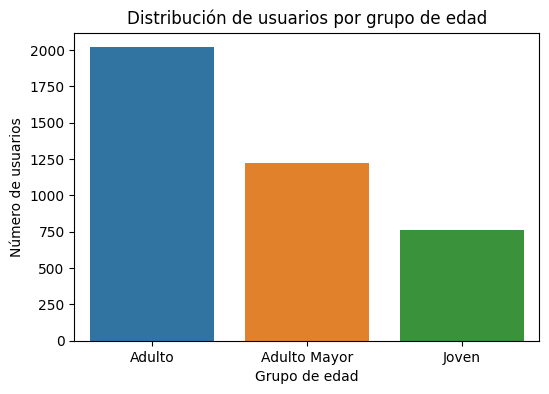

In [58]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')
plt.show()

El segmento "Adulto" concentra la mayoría de la base de usuarios (~2,020, 
~51% del total visible), más que el doble que "Adulto Mayor" (~1,220, ~31%) 
y casi tres veces "Joven" (~770, ~18%).

**Conclusiones preliminares:**
- La base de clientes está envejecida hacia el segmento adulto medio; 
  los jóvenes son la minoría, lo que puede reflejar baja penetración en 
  ese segmento o una estrategia de producto no orientada a ellos.

- Para un crecimiento, el segmento "Joven" es el 
  de mayor oportunidad relativa (menor base, potencial de adquisición).
- Si el objetivo es retención/ingresos, "Adulto" es el segmento crítico: 
  concentra más de la mitad de los usuarios.


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
## Resumen de la limpieza de datos

| Columna | Problema identificado | Cantidad | Porcentaje | Acción realizada |
|:---------|:----------------------|---------:|-----------:|:-----------------|
| **city** | Valores nulos (`NaN`) y registros con `"?"` | 469 + `"?"` | ≈11.7% | Se reemplazó `"?"` por `NaN` para unificar los valores faltantes. |
| **age** | Valor centinela `-999` | 55 | 1.38% | Se sustituyó por la mediana de la edad para conservar la distribución de la variable. |
| **reg_date** | Fechas fuera del período de estudio (año 2026) | 40 | 1.0% | Se reemplazaron por `pd.NaT` al no poder determinar la fecha correcta. |
| **churn_date** | Valores nulos | 3,534 | 88.35% | No se modificaron, ya que representan usuarios que continúan activos. |
| **date** (usage) | Fechas faltantes | 50 | 0.13% | Se documentó el problema debido a su bajo impacto. |
| **duration** | Valores nulos en registros de mensajes | 22,076 | 55.19% | No se modificaron, ya que los mensajes no tienen duración. |
| **length** | Valores nulos en registros de llamadas | 17,896 | 44.74% | No se modificaron, ya que las llamadas no tienen longitud de mensaje. |

### Conclusiones

- Se identificaron **valores faltantes**, **valores centinela** y **fechas inconsistentes**.
- Los valores nulos en **`churn_date`**, **`duration`** y **`length`** corresponden al comportamiento esperado del negocio y no representan errores.
- El valor centinela **`-999`** en la edad fue reemplazado por la mediana para evitar distorsionar el análisis.
- Los registros con fechas de **2026** en `reg_date` se marcaron como `NaT` porque el período de estudio finaliza en **2024** y no era posible recuperar la fecha correcta.
- Los registros con `"?"` en `city` se transformaron en valores nulos para mantener un formato consistente de datos faltantes.


🔍 **Segmentos por Edad**

## Segmentación por grupos de edad

Se clasificó a los usuarios en tres segmentos con base en su edad:

| Grupo de edad | Criterio |
|:---------------|:---------|
| **Joven** | Menor de 30 años |
| **Adulto** | Entre 30 y 59 años |
| **Adulto Mayor** | 60 años o más |

### Objetivo de la segmentación

La segmentación por edad permite identificar diferencias en el comportamiento de los usuarios según su etapa de vida. Esta clasificación facilita comparar el uso del servicio, analizar la adopción de los distintos planes y detectar oportunidades para desarrollar estrategias comerciales dirigidas a cada segmento.

### Insights de negocio

- **Usuarios jóvenes:** pueden ser más receptivos a promociones digitales, beneficios relacionados con mensajería o planes flexibles.
- **Usuarios adultos:** representan el segmento de mayor interés comercial, ya que suelen concentrar la mayor parte de la base de clientes y constituyen el público objetivo para la mayoría de los planes.
- **Adultos mayores:** pueden presentar patrones de uso diferentes y requerir planes más sencillos, atención personalizada o beneficios enfocados en llamadas tradicionales.


📊 **Segmentos por Nivel de Uso**

## Segmentación por nivel de uso

Los usuarios fueron clasificados en tres segmentos de acuerdo con su nivel de utilización del servicio, considerando el número de llamadas y mensajes registrados.

| Grupo de uso | Criterio |
|:--------------|:---------|
| **Bajo uso** | Menos de 5 llamadas **y** menos de 5 mensajes. |
| **Uso medio** | Menos de 10 llamadas **y** menos de 10 mensajes (sin cumplir la condición de Bajo uso). |
| **Alto uso** | 10 o más llamadas **o** 10 o más mensajes. |

### Distribución de los usuarios

| Grupo | Usuarios | Porcentaje |
|:-------|----------:|-----------:|
| **Uso medio** | 2,943 | 73.6% |
| **Bajo uso** | 778 | 19.4% |
| **Alto uso** | 279 | 7.0% |


### Insights de negocio

- **Uso medio (73.6%)**: representa la mayor parte de la cartera de clientes. Este segmento ofrece la principal oportunidad para incrementar ingresos mediante promociones, paquetes adicionales o incentivos que aumenten ligeramente el consumo.

- **Bajo uso (19.4%)**: corresponde a usuarios con una baja interacción con el servicio. Este grupo puede presentar un mayor riesgo de abandono y es un buen candidato para campañas de reactivación o planes de menor costo que aumenten su participación.

- **Alto uso (7.0%)**: aunque es el grupo más pequeño, probablemente concentra una parte importante del consumo total. Estos clientes son estratégicos para la empresa y conviene fidelizarlos mediante planes Premium, beneficios exclusivos o programas de recompensas.

### Conclusión

La base de clientes está dominada por usuarios de **uso medio**, mientras que los usuarios de **alto uso** constituyen un segmento reducido pero de alto valor. Una estrategia diferenciada para cada grupo puede contribuir a mejorar la retención de clientes y maximizar los ingresos.


# Conclusiones Generales y recomendaciones finales

## Conclusiones

El proceso de limpieza permitió obtener un conjunto de datos consistente y adecuado para el análisis. Se corrigieron los principales problemas de calidad, incluyendo valores centinela, registros inconsistentes y diferentes representaciones de datos faltantes, manteniendo intacta la información relevante para el estudio.

El análisis exploratorio mostró que la base de clientes presenta una distribución amplia de edades, sin concentraciones marcadas en un único grupo etario, lo que refleja una cartera de usuarios diversa.

La segmentación por nivel de uso evidenció que el **73.6%** de los usuarios pertenece al grupo de **Uso medio**, el **19.4%** al grupo de **Bajo uso** y el **7.0%** al grupo de **Alto uso**. Estos resultados indican que la mayoría de los clientes mantiene un consumo estable, mientras que un grupo reducido presenta un comportamiento de uso intensivo.

El análisis mediante el método del rango intercuartílico (IQR) permitió identificar valores atípicos en las variables de consumo. Sin embargo, estos registros corresponden a usuarios con un mayor nivel de utilización del servicio y no muestran evidencia de ser errores de captura, por lo que fueron conservados para representar fielmente el comportamiento real de los clientes.

## Recomendaciones

- Implementar controles de validación durante la captura de datos para evitar el uso de valores centinela, registros inconsistentes y fechas fuera del período de estudio.
- Estandarizar el registro de datos faltantes utilizando valores nulos en lugar de caracteres especiales como `"?"`.
- Analizar con mayor profundidad el comportamiento de los usuarios de **Alto uso**, ya que representan un segmento estratégico con potencial para generar una proporción importante del consumo del servicio.
- Diseñar campañas de activación para los usuarios de **Bajo uso**, con el objetivo de incrementar su participación y reducir el riesgo de abandono.
- Evaluar el comportamiento de los usuarios según el tipo de plan, grupo de edad y ciudad para identificar oportunidades de segmentación comercial y personalización de la oferta.
- Incorporar indicadores de negocio, como ingresos por usuario, rentabilidad y tasa de cancelación, para complementar el análisis y priorizar acciones sobre los segmentos de mayor valor.
- Implementar procesos periódicos de monitoreo de la calidad de los datos para garantizar que los análisis futuros se basen en información confiable y consistente.

## Impacto para el negocio

Los resultados obtenidos proporcionan una base sólida para la toma de decisiones basada en datos. La segmentación desarrollada permite identificar grupos de clientes con distintos patrones de consumo, facilitando el diseño de estrategias de fidelización, campañas de marketing más efectivas y una mejor adaptación de los planes ofrecidos. Asimismo, la mejora en la calidad de los datos incrementa la confiabilidad de los análisis posteriores y contribuye a una gestión más eficiente de la cartera de clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`